# Lifecycle Portfolio Choice Model

Three-asset lifecycle model with portfolio choice over stocks, nominal bonds, and T-bills. 
Return dynamics follow an annual VAR(1); mortality is earnings-dependent, calibrated to Chetty et al. (2016) and Catherine (2025).

| File | Contents |
|---|---|
| `model.py` | `LifecyclePortfolioModel`, `DiscretizationConfig`, `SolverConfig`; utility, bequest, income, and tax functions |
| `var.py` | VAR estimation, state/return partitioning, annualization |
| `discretization.py` | Rouwenhorst discretization, income grid, Gauss-Hermite quadrature |
| `precompute.py` | `Precompute` class; `build_model` factory |
| `solver.py` | Backward induction solver: EGM + 2D Newton-Raphson |
| `diagnostics.py` | Pre-solve calibration report, Newton failure analysis |
| `simulation.py` | Forward simulation of household lifecycle paths |
| `earnings_dependent_mortality.py` | Survival probability calibration |

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
from pathlib import Path

from model import DiscretizationConfig, SolverConfig
from var import build_nominal_system1_var_config, annualize_var_config
from precompute import build_model, Precompute
from solver import run_lifecycle_solver
from diagnostics import print_model_diagnostic_report, diagnose_terminal_portfolio_states
from simulation import simulate_lifecycle

### Step 1: Estimate VAR
Estimate quarterly VAR from data, then annualise to annual frequency.
The DP model uses ANNUAL periods (ages 22-99, beta=0.96).

In [4]:
# Resolve dataset path robustly regardless of kernel launch directory.
_path_candidates = [
    Path("var_dataset.csv"),
    Path("TIPS_MODEL/var_dataset.csv"),
    Path("../TIPS_MODEL/var_dataset.csv"),
]
_VAR_CSV = next((p for p in _path_candidates if p.exists()), None)
if _VAR_CSV is None:
    raise FileNotFoundError(
        "Could not find var_dataset.csv. Tried: "
        + ", ".join(str(p) for p in _path_candidates)
    )

var_config_q, var_res, var_data = build_nominal_system1_var_config(csv_path=str(_VAR_CSV))
var_config = annualize_var_config(var_config_q, h=4)

VAR ESTIMATION SUMMARY
Estimation mode: restricted
Sample: 1980-03-31 to 2025-12-31
Columns: ['rtb', 'xr', 'xb', 'y_nom', 'dp']
State indices: (0, 3, 4)
Return indices: (1, 2)
VAR k=5, T=183
Max |Phi[:, return_lag_cols]|: 0.000e+00

Intercept vector (const):
[-0.01804   0.308322 -0.032652  0.001431 -0.259384]

Residual correlation matrix:
[[ 1.     -0.0545  0.3102 -0.3295  0.054 ]
 [-0.0545  1.     -0.0919  0.0855 -0.9735]
 [ 0.3102 -0.0919  1.     -0.9973  0.094 ]
 [-0.3295  0.0855 -0.9973  1.     -0.0882]
 [ 0.054  -0.9735  0.094  -0.0882  1.    ]]

Equation R2:
  rtb: 0.4874
  xr: 0.0609
  xb: 0.0214
  y_nom: 0.9645
  dp: 0.9663
annualize_var_config: compounded 4 quarters to 1 annual period.
  Phi_11 diagonal (annual): [0.01694945 0.86113351 0.80693056]
  xr: quarterly mean=1.34%  annual mean=5.36%  ratio=4.0000
  xb: quarterly mean=0.59%  annual mean=2.36%  ratio=4.0000


### Step 2: Parameters

All numerical choices for the model run are set here.

#### Economic calibration

In [5]:
# --- Preferences & bequest ---
gamma = 3.0          # relative risk aversion
beta  = 0.96         # annual discount factor
b_bar = 10           # bequest horizon in years (bond maturity, Catherine 2025)

# --- Lifecycle ages ---
start_age    = 22    # age at labor market entry
retire_age   = 67    # age of retirement
terminal_age = 99    # final model period

# --- Age-earnings profile (Catherine 2025) ---
# log y = b0 + b1*Age + b2*Age^2/10 + b3*Age^3/100
b0, b1, b2, b3 = -6.142, 0.3040, -0.051, 0.002586   # intercept, linear, quadratic/10, cubic/100

# --- Persistent income process (Guvenen et al. 2022) ---
# Two-component mixture: shocks drawn from high- or low-variance component each period.
rho = 0.991          # AR(1) on log permanent income
pz  = 0.176          # weight on high-variance mixture component
mu_eta1    = -0.524;  sigma_eta1 = 0.113   # low-variance component: mean, std dev
mu_eta2    = -(pz / (1.0 - pz)) * mu_eta1  # high-variance component mean (zero-mean condition, derived)
sigma_eta2 = 0.046                          # high-variance component std dev

# --- Transitory income shocks ---
mu_eps1    = 0.134;  sigma_eps1 = 0.762    # mixture component 1: mean, std dev
mu_eps2    = 0.0;    sigma_eps2 = 0.055    # mixture component 2: mean, std dev
pe         = 0.044   # mixing weight on transitory shock component 1

# --- Portfolio constraints ---
constrained = True   # False = allow leverage / short positions

base_config = {
    "beta": beta, "gamma": gamma, "b_bar": b_bar,
    "start_age": start_age, "retire_age": retire_age, "terminal_age": terminal_age,
    "b0": b0, "b1": b1, "b2": b2, "b3": b3,
    "rho": rho, "pz": pz,
    "mu_eta1": mu_eta1, "sigma_eta1": sigma_eta1,
    "mu_eta2": mu_eta2, "sigma_eta2": sigma_eta2,
    "pe": pe,
    "mu_eps1": mu_eps1, "sigma_eps1": sigma_eps1,
    "mu_eps2": mu_eps2, "sigma_eps2": sigma_eps2,
    "constrained": constrained,
}

#### Discretization and solver

Grid sizes control the accuracy of the state-space approximation. 
Solver fields below are the primary tuning knobs; numerical stability constants use class defaults in `model.py`.

In [6]:
disc_config = DiscretizationConfig(
    n_wealth=150,
    n_savings=150,
    state_grid_sizes=(5, 5, 5),    # (rtb, y_nom, dp) -- 125 states; use (7,7,7) for production
    n_z=5,                         # Rouwenhorst grid points for permanent income (11 for production)
    n_eps_nodes=5,                 # Gauss-Hermite nodes for transitory shock (doubled internally)
    n_ret_nodes_1d=3,              # quadrature order per return dimension; K=1 -> point mass at conditional mean
)

solver_config = SolverConfig(
    # --- Convergence ---
    tol=1e-7,
    max_iter=20,                   # constrained Newton
    max_iter_unconstrained=5000,   # unconstrained Newton 
    # --- Initial portfolio guess ---
    init_alpha_s=0.1,              # initial stock share
    init_alpha_b=0.4,              # initial bond share
    # --- Step control ---
    step_damp_constrained=0.2,     # max Newton step length (constrained)
    step_damp_unconstrained=0.3,   # max Newton step length (unconstrained)
    # numerical stability constants -> class defaults
)

#### Simulation

In [29]:
# ── Simulation defaults ──────────────────────────────────────────────────────

sim_defaults = dict(
    n_simulations       = 10_000,
    seed                = 42,
    initial_wealth      = 0.1,
    initial_z           = "normal",
    initial_z_normal_std = 0.652,
    initial_state       = "median",
    return_draw_mode    = "monte_carlo",
)

def run_sim(label="baseline", verbose=True, **overrides):
    """Run simulate_lifecycle with defaults, overriding any kwargs. Returns (label, sim_data)."""
    kw = {**sim_defaults, **overrides}
    print(f"\n{'─'*40}\nSimulation: {label}\n{'─'*40}")
    sd = simulate_lifecycle(C_mat, S_mat, B_mat, pc, model, verbose=verbose, **kw)
    sd['label'] = label
    return sd

### Step 3: Build Model and Precompute

Assembles `LifecyclePortfolioModel` from `base_config` and the estimated VAR, 
then precomputes grids, transitions, and income quadrature.

In [8]:
model = build_model(base_config, var_config, verbose=True)
pc    = Precompute(model, disc_config)

VAR PARTITION SUMMARY
Full variables: ['rtb', 'xr', 'xb', 'y_nom', 'dp']
State variables (on grid): ['rtb', 'y_nom', 'dp']
Return variables (integrated): ['xr', 'xb']

Slow-state sub-VAR:
  Phi_11 eigenvalues (|.|): [0.9162, 0.7656, 0.0032]
  Max |eigenvalue| = 0.9162  --  STATIONARY

Restriction check (should be near zero if imposed):
  ||Phi_12|| = 0.000000e+00   (lagged returns -> states)
  ||Phi_22|| = 0.000000e+00   (lagged returns -> returns)

Conditional return variance explained by slow-state conditioning:
  xr:  89.76%  explained  (residual var = 0.001805)
  xb:  98.82%  explained  (residual var = 0.000148)

  EARNINGS-DEPENDENT MORTALITY CALIBRATION
  Catherine (2025) eq. (35), conditioned on persistent income z
  Income params: rho=0.9910  sigma_z=1.8697
  z grid: 5 pts  [-5.6090, 5.6090]
  SSA table: 2017 (2020 TR), gender-averaged
  Targets: Chetty et al. (2016), race-adjusted, gender-averaged

         z  pctile      chi   target   actual  err(yr)
  ──────── ─────── ─────

### Step 4: Pre-Solve Diagnostics

In [9]:
# periods_per_year=1 because model uses ANNUAL parameters.
print_model_diagnostic_report(model, pc, periods_per_year=1)

# Terminal-stage portfolio diagnostic before the full lifecycle solve.
terminal_diag = diagnose_terminal_portfolio_states(model, pc)


  1.  PREFERENCES & LIFECYCLE

  --- Utility & bequest ---
  gamma  = 3.000   (CRRA risk aversion)
  beta   = 0.960000  per period   ->   0.960000  annualized
  b_bar  = 10   (bequest horizon in years, Catherine 2025)

  --- Lifecycle ---
  Ages:  22 - 99   (78 periods total)
  Retirement at 67:   45 working periods,  33 retirement periods

  --- Survival probabilities at key ages (earnings-dependent) ---
   Age       low-z       mid-z      high-z
    25     0.99813     0.99909     0.99942
    30     0.99749     0.99878     0.99922
    40     0.99610     0.99810     0.99878
    50     0.99314     0.99666     0.99786
    55     0.98988     0.99507     0.99684
    60     0.98479     0.99260     0.99525
    65     0.97814     0.98936     0.99317
    70     0.96911     0.98497     0.99035
    75     0.95232     0.97679     0.98511
    80     0.92076     0.96143     0.97525

  2.  INCOME PROCESS

  --- Persistent AR(1) with mixture-normal innovations ---
  rho        = 0.99100  (per-period

### Step 5: Solve
First call triggers Numba JIT compilation (~30-60s); subsequent calls are fast.

In [10]:
C_mat, S_mat, B_mat, diagnostics = run_lifecycle_solver(model, pc, solver_config=solver_config)


LIFECYCLE PORTFOLIO SOLVER  (EGM + 2D Newton)
  Mode: CONSTRAINED
  Solver: SolverConfig(tol=1e-07, max_iter=20, max_iter_unconstrained=5000, edge_max_iter=8, init_alpha_s=0.1, init_alpha_b=0.4, step_damp_constrained=0.2, step_damp_unconstrained=0.3, grad_step_size=0.05, tiny_savings=1e-06, corner_tol=1e-08, edge_accept_factor=10.0, singular_det=1e-15, grad_denom_eps=1e-10, min_wealth_inv=1e-10, min_consumption=1e-10, min_return_power=1e-15, prob_skip_threshold=1e-12, euler_inv_floor=1e-20, egm_anchor=1e-10)
  Discretization: DiscretizationConfig(n_wealth=150, wealth_min=0.0001, wealth_max=200.0, n_savings=150, savings_min=1e-08, state_grid_sizes=(5, 5, 5), n_z=5, n_eps_nodes=5, n_ret_nodes_1d=3, consistency_tol_warn=0.02, consistency_tol_error=0.1)
  Ages 22–99  (78 periods)
  Grids: n_w=150, n_s=150, n_z=5, N_state=125
  gamma=3.0, beta=0.96, b_bar=10
  States per period: 5 × 125 = 625

  Terminal condition (age 99) ... done  [c range: 0.000–24.439]  [portfolio: 5 interior, 120 corn

In [11]:
# Re-run the reusable terminal diagnostic if you want to inspect failures again
# after changing the discretization, leverage regime, or solver settings.
terminal_diag = diagnose_terminal_portfolio_states(model, pc)


TERMINAL PORTFOLIO DIAGNOSTIC
Mode: CONSTRAINED
States: 125  interior=5  corner/edge=120  fail=0
Solver residuals: min=0.000e+00  median=0.000e+00  max=1.551e-05
No terminal failures detected.


### Step 6: Simulate Households
Run a first lifecycle simulation using the solved policy functions.

In [30]:
sim_data = run_sim("baseline")


────────────────────────────────────────
Simulation: baseline
────────────────────────────────────────
SIMULATING LIFECYCLE PATHS
  Households:          10,000
  Ages:                22 to 99 (78 periods)
  Retirement age:      67 (index 45)
  Income x fin state:  5 z x 125 s = 625 combined states
  Return quad nodes:   9 (K=3 per dim)
  Return draw mode:    monte_carlo
  sigma_resid (xr,xb): 0.0425, 0.0121

  Initial wealth: 0.100 before income
  Initial x = wealth + Y0  |  mean=0.292  p25=0.254  p75=0.266
  Initial z state:     normal
  Initial z sigma:     0.652
  Initial fin state:   median

  Running simulation...

  Simulation complete: 0.06s
  Survival to age 99: 5.4%
  Median death age: 85

  Cash-on-hand by phase
  Phase                age  alive%      p25      p50      p75
  Start                 22  100.0%    0.254    0.254    0.266
  Mid-work              44  96.9%    1.930    2.199    2.585
  Pre-retire            66  86.3%    3.485    4.275    5.390
  Retire             

### Step 7: Results & Plotting
Add your analysis and plotting code here.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ── Shared helper ────────────────────────────────────────────────────────────

def cross_sectional_stats(data, alive):
    """Compute cross-sectional mean and percentiles at each age, conditional on survival."""
    n_ages = data.shape[1]
    out = {k: np.zeros(n_ages) for k in
           ['mean', 'std', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'n_alive']}
    for t in range(n_ages):
        mask = alive[:, t]
        n = np.sum(mask)
        out['n_alive'][t] = n
        if n > 0:
            d = data[mask, t]
            out['mean'][t] = np.mean(d)
            out['std'][t]  = np.std(d)
            for tag, q in [('p5',5),('p10',10),('p25',25),('p50',50),
                           ('p75',75),('p90',90),('p95',95)]:
                out[tag][t] = np.percentile(d, q)
    return out

# ── Colour palette ───────────────────────────────────────────────────────────

COLORS = {
    'consumption': '#2ecc71',
    'income':      '#3498db',
    'wealth':      '#9b59b6',
    'stocks':      '#e74c3c',
    'bonds':       '#1abc9c',
    'bills':       '#f39c12',
}

#### Figure 1 — Mean Lifecycle Profiles
Mean consumption, labour income, and wealth (cash-on-hand) over the lifecycle, conditional on survival.

**Simulation initialisation:** 10,000 households enter at age 22 with pre-labour-income wealth of 0.1 (model units). 
Persistent income $z_0$ is drawn from $N(0, 0.652^2)$ and mapped to the nearest discrete grid point ($n_z=5$). 
All households start at the median financial state (rtb, $y_{\mathrm{nom}}$, dp) on the $5\times5\times5$ state grid. 
Returns are drawn via Monte Carlo from the conditional normal each period. Seed = 42.

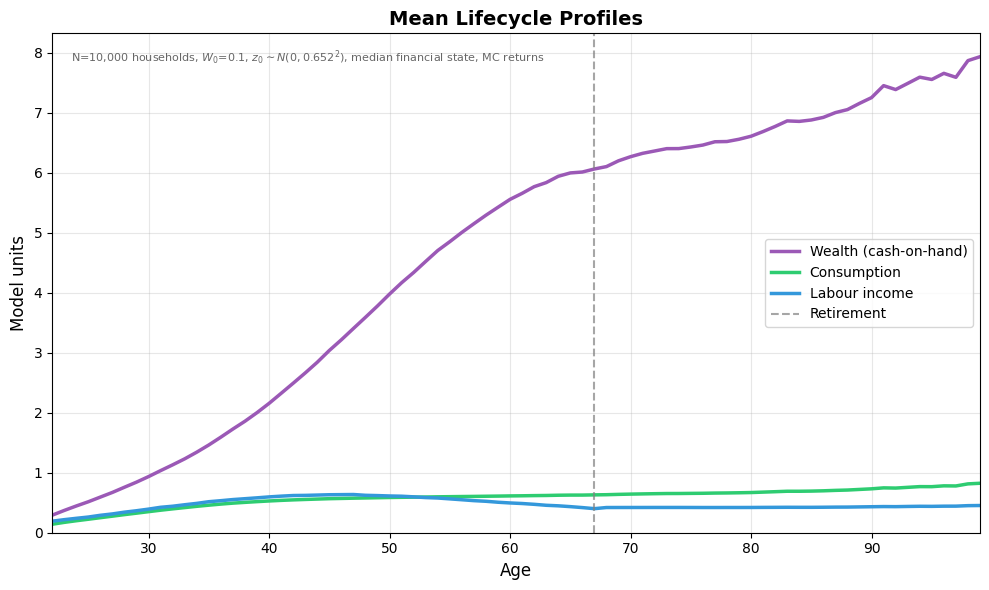

In [32]:
ages  = sim_data['ages']
alive = sim_data['alive']

c_stats = cross_sectional_stats(sim_data['c'], alive)
y_stats = cross_sectional_stats(sim_data['income'], alive)
w_stats = cross_sectional_stats(sim_data['x'], alive)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ages, w_stats['mean'], color=COLORS['wealth'],      lw=2.5, label='Wealth (cash-on-hand)')
ax.plot(ages, c_stats['mean'], color=COLORS['consumption'],  lw=2.5, label='Consumption')
ax.plot(ages, y_stats['mean'], color=COLORS['income'],       lw=2.5, label='Labour income')

ax.axvline(model.retire_age, color='gray', ls='--', lw=1.5, alpha=0.7, label='Retirement')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Model units', fontsize=12)
ax.set_title('Mean Lifecycle Profiles', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(ages[0], ages[-1])
ax.set_ylim(bottom=0)

# Annotation: simulation description
desc = (f"N={np.sum(alive[:,0]):,.0f} households, "
        f"$W_0$=0.1, $z_0 \\sim N(0, {initial_z_normal_std}^2)$, "
        f"median financial state, MC returns")
ax.text(0.02, 0.97, desc, transform=ax.transAxes, fontsize=8,
        va='top', ha='left', color='0.4')

plt.tight_layout()
plt.show()

#### Figure 2 — Mean Portfolio Allocation Over the Lifecycle
Mean share allocated to stocks, nominal bonds, and bills at each age, conditional on survival. Same simulation as Figure 1.

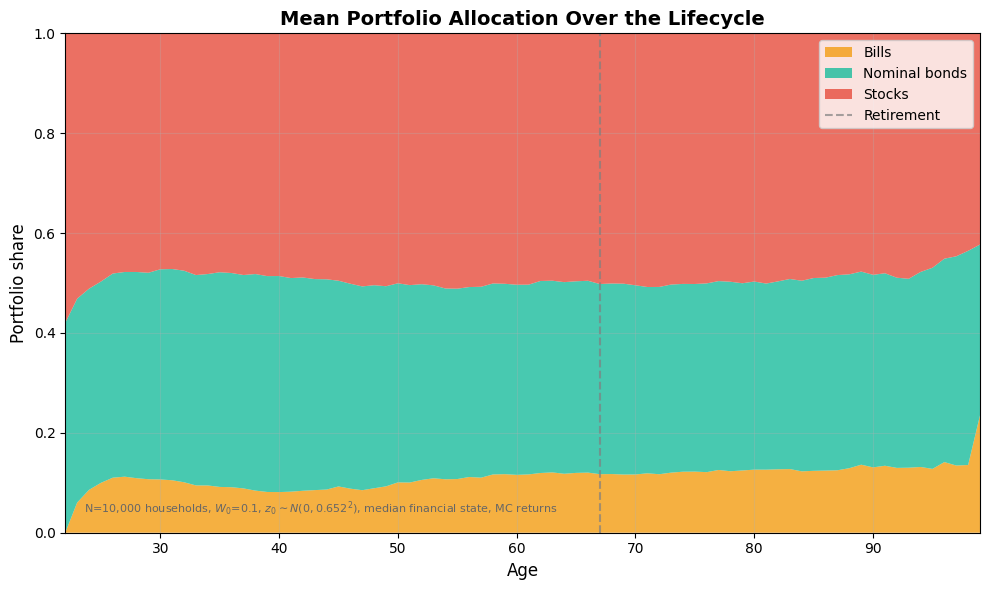

In [33]:
as_stats = cross_sectional_stats(sim_data['alpha_s'], alive)
ab_stats = cross_sectional_stats(sim_data['alpha_b'], alive)
abill_stats = cross_sectional_stats(sim_data['alpha_bill'], alive)

fig, ax = plt.subplots(figsize=(10, 6))

ax.stackplot(ages,
             abill_stats['mean'], ab_stats['mean'], as_stats['mean'],
             labels=['Bills', 'Nominal bonds', 'Stocks'],
             colors=[COLORS['bills'], COLORS['bonds'], COLORS['stocks']],
             alpha=0.8)

ax.axvline(model.retire_age, color='gray', ls='--', lw=1.5, alpha=0.7, label='Retirement')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Portfolio share', fontsize=12)
ax.set_title('Mean Portfolio Allocation Over the Lifecycle', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(ages[0], ages[-1])
ax.set_ylim(0, 1)

desc = (f"N={np.sum(alive[:,0]):,.0f} households, "
        f"$W_0$=0.1, $z_0 \\sim N(0, {initial_z_normal_std}^2)$, "
        f"median financial state, MC returns")
ax.text(0.02, 0.03, desc, transform=ax.transAxes, fontsize=8,
        va='bottom', ha='left', color='0.4')

plt.tight_layout()
plt.show()

#### Figure 3 — Consumption Smoothing: Consumption vs Income Fan Chart
Median consumption and income with interquartile range bands. The narrow consumption band relative to the wide income band demonstrates lifecycle consumption smoothing.

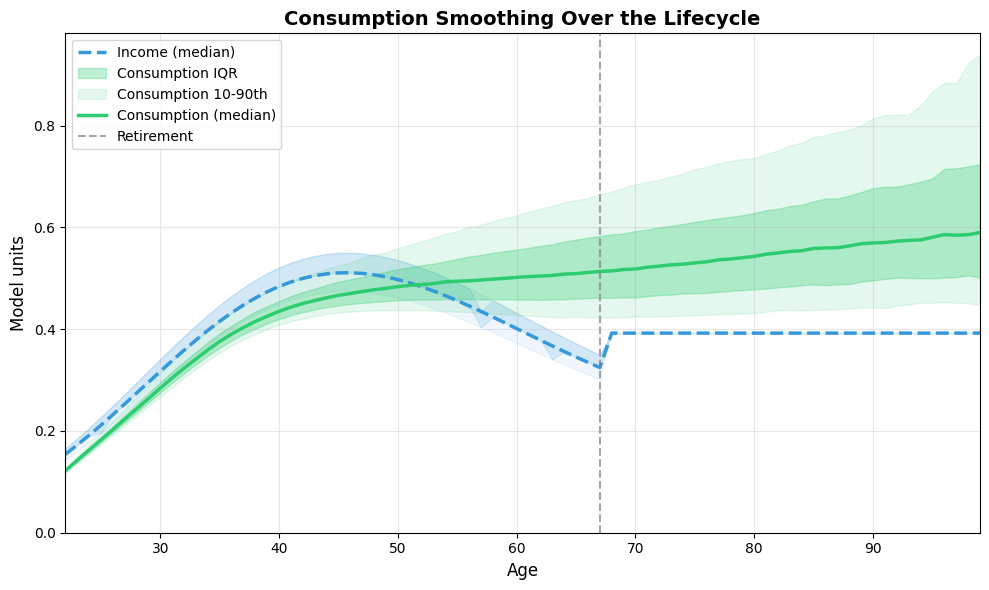

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

# Income fan (lighter)
ax.fill_between(ages, y_stats['p25'], y_stats['p75'],
                alpha=0.15, color=COLORS['income'])
ax.fill_between(ages, y_stats['p10'], y_stats['p90'],
                alpha=0.08, color=COLORS['income'])
ax.plot(ages, y_stats['p50'], color=COLORS['income'], lw=2.5,
        ls='--', label='Income (median)')

# Consumption fan (darker)
ax.fill_between(ages, c_stats['p25'], c_stats['p75'],
                alpha=0.3, color=COLORS['consumption'], label='Consumption IQR')
ax.fill_between(ages, c_stats['p10'], c_stats['p90'],
                alpha=0.12, color=COLORS['consumption'], label='Consumption 10-90th')
ax.plot(ages, c_stats['p50'], color=COLORS['consumption'], lw=2.5,
        label='Consumption (median)')

ax.axvline(model.retire_age, color='gray', ls='--', lw=1.5, alpha=0.7, label='Retirement')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Model units', fontsize=12)
ax.set_title('Consumption Smoothing Over the Lifecycle', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(ages[0], ages[-1])
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

#### Figure 4 — Portfolio Allocation by Income Quintile
Mean portfolio shares at age 45, split by persistent income state $z$. Tests whether high earners hold more bonds (larger bond-like human capital induces substitution toward equities, but the hedging channel may push bonds higher for agents with longer-duration income streams).

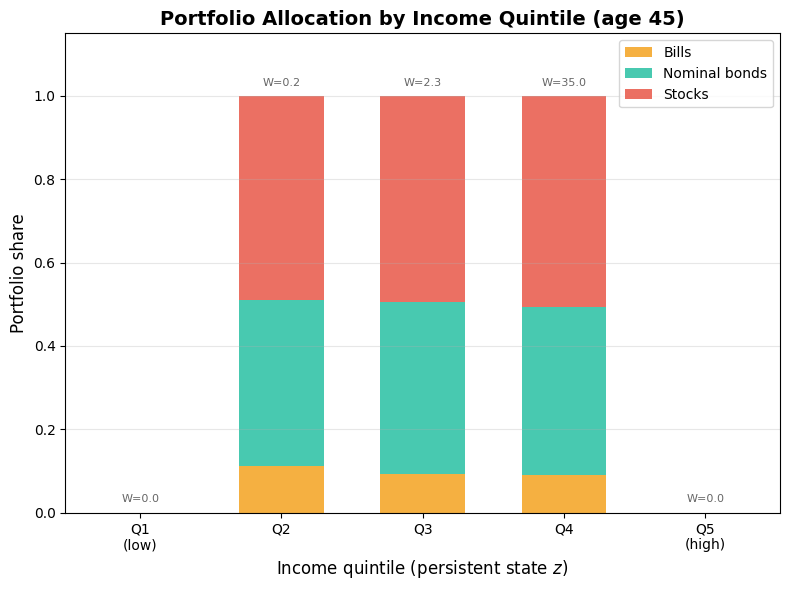

In [35]:
target_age = 45
t_idx = target_age - model.start_age

alive_t = sim_data['alive'][:, t_idx]
z_vals  = sim_data['z_idx'][alive_t, t_idx]

# Build quintile bins from the n_z grid points
n_z = pc.n_z
quintile_edges = np.linspace(-0.5, n_z - 0.5, 6)  # 5 equal-width bins over z indices
quintile_labels = ['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)']
q_assign = np.digitize(z_vals, quintile_edges[1:-1])  # 0..4

as_q, ab_q, abill_q, w_q = [], [], [], []
for q in range(5):
    mask = q_assign == q
    if np.sum(mask) == 0:
        as_q.append(0); ab_q.append(0); abill_q.append(0); w_q.append(0)
        continue
    # Index back into the full arrays using alive mask
    alive_indices = np.where(alive_t)[0]
    q_indices = alive_indices[mask]
    as_q.append(np.mean(sim_data['alpha_s'][q_indices, t_idx]))
    ab_q.append(np.mean(sim_data['alpha_b'][q_indices, t_idx]))
    abill_q.append(np.mean(sim_data['alpha_bill'][q_indices, t_idx]))
    w_q.append(np.median(sim_data['x'][q_indices, t_idx]))

as_q, ab_q, abill_q = np.array(as_q), np.array(ab_q), np.array(abill_q)

fig, ax = plt.subplots(figsize=(8, 6))
x_pos = np.arange(5)
width = 0.6

ax.bar(x_pos, abill_q, width, label='Bills', color=COLORS['bills'], alpha=0.8)
ax.bar(x_pos, ab_q, width, bottom=abill_q, label='Nominal bonds', color=COLORS['bonds'], alpha=0.8)
ax.bar(x_pos, as_q, width, bottom=abill_q + ab_q, label='Stocks', color=COLORS['stocks'], alpha=0.8)

# Annotate median wealth above each bar
for i in range(5):
    ax.text(x_pos[i], abill_q[i] + ab_q[i] + as_q[i] + 0.02,
            f'W={w_q[i]:.1f}', ha='center', va='bottom', fontsize=8, color='0.4')

ax.set_xticks(x_pos)
ax.set_xticklabels(quintile_labels)
ax.set_xlabel('Income quintile (persistent state $z$)', fontsize=12)
ax.set_ylabel('Portfolio share', fontsize=12)
ax.set_title(f'Portfolio Allocation by Income Quintile (age {target_age})',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Figure 5 — Portfolio Allocation Fan Chart
Mean portfolio share for each asset with interquartile range bands, showing cross-sectional dispersion in portfolio choice over the lifecycle.

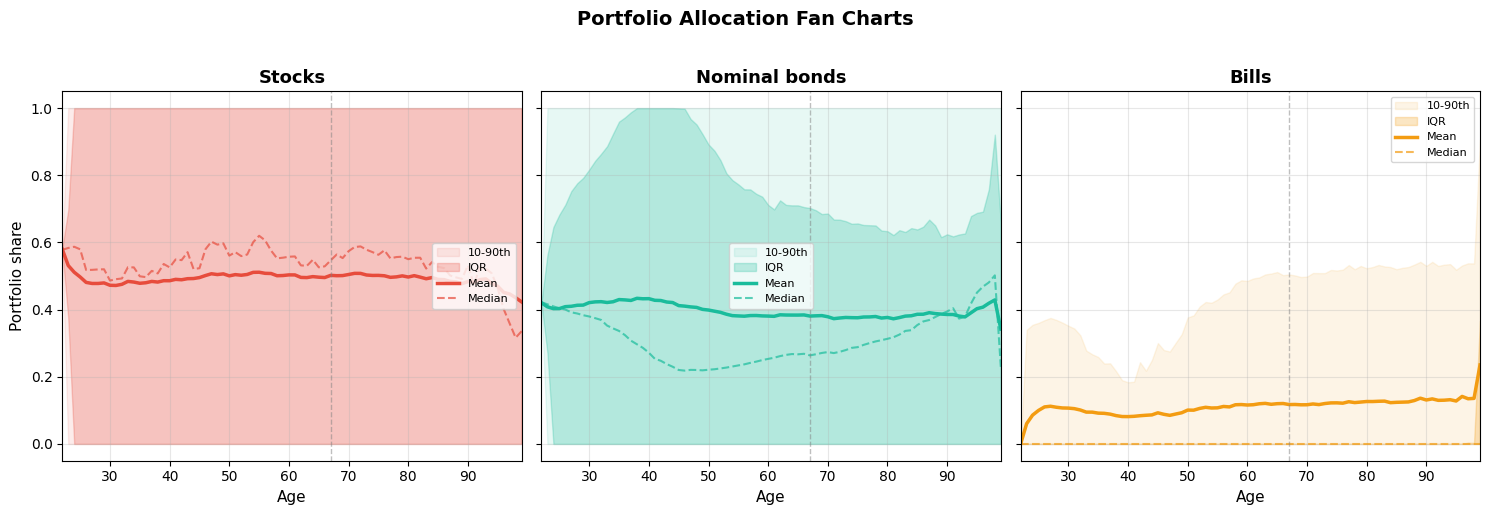

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, stats, color, label in zip(
    axes,
    [as_stats, ab_stats, abill_stats],
    [COLORS['stocks'], COLORS['bonds'], COLORS['bills']],
    ['Stocks', 'Nominal bonds', 'Bills'],
):
    ax.fill_between(ages, stats['p10'], stats['p90'],
                    alpha=0.10, color=color, label='10-90th')
    ax.fill_between(ages, stats['p25'], stats['p75'],
                    alpha=0.25, color=color, label='IQR')
    ax.plot(ages, stats['mean'], color=color, lw=2.5, label='Mean')
    ax.plot(ages, stats['p50'], color=color, lw=1.5, ls='--', alpha=0.7, label='Median')

    ax.axvline(model.retire_age, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Age', fontsize=11)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(ages[0], ages[-1])

axes[0].set_ylabel('Portfolio share', fontsize=11)
axes[0].set_ylim(-0.05, 1.05)

fig.suptitle('Portfolio Allocation Fan Charts', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Scenario: High Dividend-Price Ratio & High Nominal Yield
Run a simulation where all households start in a "value" macro regime: dp and y_nom at the top of their grids, rtb at median. This represents a world with cheap equities and high bond yields — e.g. the early 1980s.

In [37]:
# Identify the joint state index for: rtb=median, y_nom=high, dp=high
n_rtb, n_ynom, n_dp = pc.state_grid_sizes
mid_rtb = n_rtb // 2     # median bill rate
high_ynom = n_ynom - 1    # top of yield grid
high_dp = n_dp - 1        # top of dp grid

# Find the joint index matching these marginal indices
target_marginal = np.array([mid_rtb, high_ynom, high_dp])
match = np.where((pc.state_indices == target_marginal).all(axis=1))[0]
high_dp_ynom_state = int(match[0])

# Report what this state looks like
s_vals = pc.state_grid[high_dp_ynom_state]
print(f"State index: {high_dp_ynom_state}")
print(f"  rtb   = {s_vals[0]:.4f}  ({s_vals[0]*4:.2f}% annualised)")
print(f"  y_nom = {s_vals[1]:.4f}  ({s_vals[1]*4:.2f}% annualised)")
print(f"  dp    = {s_vals[2]:.4f}  (log D/P)")

# Run simulation
init_state_arr = np.full(sim_defaults['n_simulations'], high_dp_ynom_state, dtype=np.int32)
sim_high = run_sim("high dp + high yield", initial_state=init_state_arr)

State index: 74
  rtb   = -0.0008  (-0.00% annualised)
  y_nom = 0.0202  (0.08% annualised)
  dp    = -3.6743  (log D/P)

────────────────────────────────────────
Simulation: high dp + high yield
────────────────────────────────────────
SIMULATING LIFECYCLE PATHS
  Households:          10,000
  Ages:                22 to 99 (78 periods)
  Retirement age:      67 (index 45)
  Income x fin state:  5 z x 125 s = 625 combined states
  Return quad nodes:   9 (K=3 per dim)
  Return draw mode:    monte_carlo
  sigma_resid (xr,xb): 0.0425, 0.0121

  Initial wealth: 0.100 before income
  Initial x = wealth + Y0  |  mean=0.292  p25=0.254  p75=0.266
  Initial z state:     normal
  Initial z sigma:     0.652
  Initial fin state:   custom array

  Running simulation...

  Simulation complete: 0.06s
  Survival to age 99: 5.4%
  Median death age: 85

  Cash-on-hand by phase
  Phase                age  alive%      p25      p50      p75
  Start                 22  100.0%    0.254    0.254    0.266
  Mi

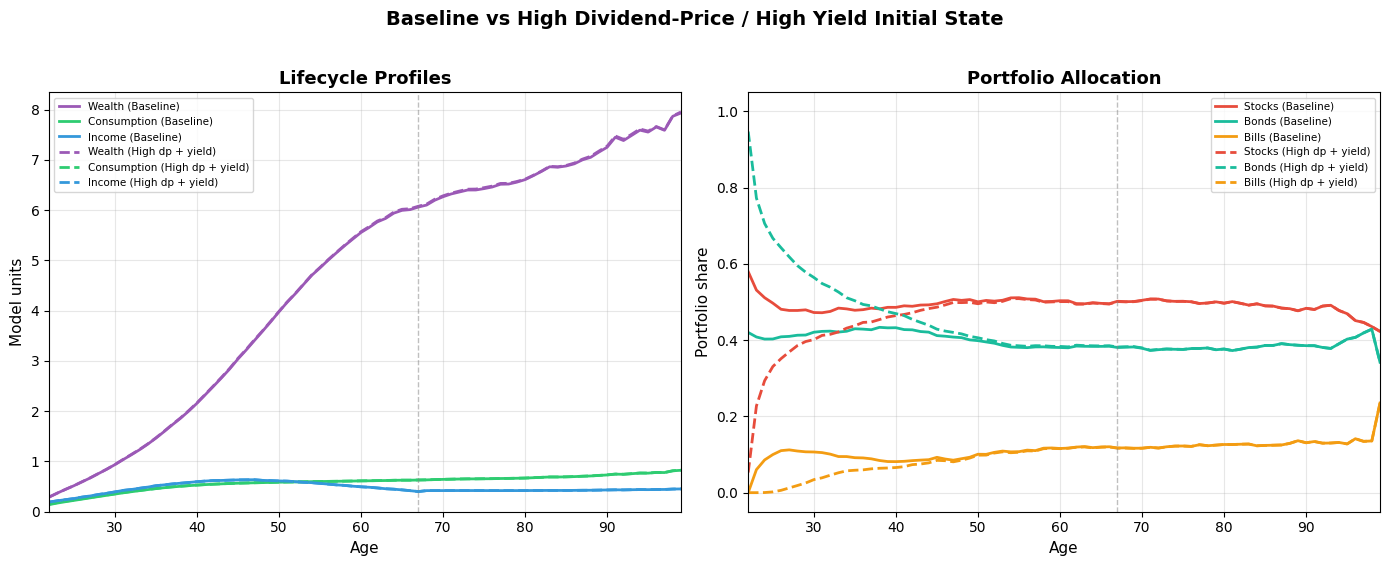

In [38]:
# Compare baseline vs high-dp/high-yield: lifecycle profiles and portfolio allocation
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for sd, ls, tag in [(sim_data, '-', 'Baseline'), (sim_high, '--', 'High dp + yield')]:
    a = sd['alive']
    cs = cross_sectional_stats(sd['c'], a)
    ys = cross_sectional_stats(sd['income'], a)
    ws = cross_sectional_stats(sd['x'], a)

    axes[0].plot(ages, ws['mean'], color=COLORS['wealth'],      lw=2, ls=ls, label=f'Wealth ({tag})')
    axes[0].plot(ages, cs['mean'], color=COLORS['consumption'], lw=2, ls=ls, label=f'Consumption ({tag})')
    axes[0].plot(ages, ys['mean'], color=COLORS['income'],      lw=2, ls=ls, label=f'Income ({tag})')

for sd, ls, tag in [(sim_data, '-', 'Baseline'), (sim_high, '--', 'High dp + yield')]:
    a = sd['alive']
    ss = cross_sectional_stats(sd['alpha_s'], a)
    bs = cross_sectional_stats(sd['alpha_b'], a)
    bl = cross_sectional_stats(sd['alpha_bill'], a)

    axes[1].plot(ages, ss['mean'], color=COLORS['stocks'], lw=2, ls=ls, label=f'Stocks ({tag})')
    axes[1].plot(ages, bs['mean'], color=COLORS['bonds'],  lw=2, ls=ls, label=f'Bonds ({tag})')
    axes[1].plot(ages, bl['mean'], color=COLORS['bills'],  lw=2, ls=ls, label=f'Bills ({tag})')

for ax in axes:
    ax.axvline(model.retire_age, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Age', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(ages[0], ages[-1])
    ax.legend(loc='best', fontsize=7.5)

axes[0].set_ylabel('Model units', fontsize=11)
axes[0].set_title('Lifecycle Profiles', fontsize=13, fontweight='bold')
axes[0].set_ylim(bottom=0)

axes[1].set_ylabel('Portfolio share', fontsize=11)
axes[1].set_title('Portfolio Allocation', fontsize=13, fontweight='bold')
axes[1].set_ylim(-0.05, 1.05)

fig.suptitle('Baseline vs High Dividend-Price / High Yield Initial State',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Investigation: Terminal Condition
Check the terminal consumption-to-wealth ratio from the policy function and diagnose whether the bequest motive is too strong.

In [ ]:
from math import exp as mexp

# ── Terminal consumption ratio from the policy function ──────────────────────
T = pc.n_age - 1  # terminal period index (age 99)
mid_z = pc.n_z // 2
mid_s = pc.N_state // 2

print("=" * 70)
print("TERMINAL CONDITION DIAGNOSTIC")
print("=" * 70)

# 1. Policy c/x ratio at terminal age across the wealth grid
c_terminal = C_mat[T, mid_z, mid_s, :]
ratio_cx = c_terminal / np.maximum(pc.wealth_grid, 1e-15)
print(f"\nTerminal c/x ratio at median (z, state):")
print(f"  min = {ratio_cx.min():.6f},  max = {ratio_cx.max():.6f}")
print(f"  At w=1:  c/x = {np.interp(1.0, pc.wealth_grid, ratio_cx):.6f}")
print(f"  At w=5:  c/x = {np.interp(5.0, pc.wealth_grid, ratio_cx):.6f}")
print(f"  At w=10: c/x = {np.interp(10.0, pc.wealth_grid, ratio_cx):.6f}")
print(f"  → Agent consumes {ratio_cx.mean()*100:.1f}% of wealth at terminal age")

# 2. Reproduce the terminal formula to check omega and ratio
A_mid = pc.annuity_factors[mid_s]
R_bill = mexp(pc.r_bill_grid[mid_s])
alpha_s_T = S_mat[T, mid_z, mid_s, pc.n_w // 2]
alpha_b_T = B_mat[T, mid_z, mid_s, pc.n_w // 2]

# Approximate E[R_port^(1-gamma)] at this state
from solver import build_gross_return_arrays
Rx_stock, Rx_bond = build_gross_return_arrays(pc.mu_r[mid_s, :, :], pc.ret_nodes)
alpha_bill = 1.0 - alpha_s_T - alpha_b_T
R_port_scenarios = alpha_s_T * R_bill * Rx_stock + alpha_b_T * R_bill * Rx_bond + alpha_bill * R_bill
Pi_row = pc.Pi_state[mid_s, :]
weights_2d = Pi_row[:, None] * pc.ret_weights[None, :]
moment = np.sum(weights_2d * R_port_scenarios ** (1.0 - model.gamma))
omega = model.b_bar * A_mid ** (model.gamma - 1.0) * moment
ratio_val = (model.beta * omega) ** (-1.0 / model.gamma)

print(f"\n── Bequest formula components ──")
print(f"  A(y_nom) = {A_mid:.4f}  (annuity factor at median state)")
print(f"  R_bill   = {R_bill:.6f}")
print(f"  alpha_s  = {alpha_s_T:.4f},  alpha_b = {alpha_b_T:.4f}")
print(f"  E[R_port^(1-gamma)] = {moment:.6f}")
print(f"  b_bar    = {model.b_bar}")
print(f"  omega    = b_bar * A^(gamma-1) * moment = {omega:.6f}")
print(f"  beta*omega = {model.beta * omega:.6f}")
print(f"  ratio    = (beta*omega)^(-1/gamma) = {ratio_val:.6f}")
print(f"  c/x      = ratio / (ratio + 1) = {ratio_val / (ratio_val + 1.0):.6f}")

# 3. Compare u'(c) vs b'(W) at median retirement wealth
w_med = np.median(sim_data['x'][sim_data['alive'][:, T], T]) if np.any(sim_data['alive'][:, T]) else 5.0
c_at_wmed = np.interp(w_med, pc.wealth_grid, c_terminal)
a_at_wmed = w_med - c_at_wmed
u_prime_c = c_at_wmed ** (-model.gamma)
# b'(W) = b_bar * (W/A)^(-gamma) / A
b_prime_W = model.b_bar * (a_at_wmed / A_mid) ** (-model.gamma) / A_mid

print(f"\n── Marginal utility comparison at median terminal wealth ──")
print(f"  Median terminal W = {w_med:.4f}")
print(f"  c(W) = {c_at_wmed:.4f},  savings = {a_at_wmed:.4f}")
print(f"  u'(c) = {u_prime_c:.4f}")
print(f"  b'(a) = {b_prime_W:.4f}  (before beta*R_port)")
print(f"  Ratio u'(c) / b'(a) = {u_prime_c / b_prime_W:.4f}")

# 4. c/x ratio across ALL ages at median state (shows drawdown pattern)
cx_by_age = np.zeros(pc.n_age)
for t in range(pc.n_age):
    c_t = C_mat[t, mid_z, mid_s, :]
    cx_t = c_t / np.maximum(pc.wealth_grid, 1e-15)
    # Evaluate at a representative wealth level
    cx_by_age[t] = np.interp(3.0, pc.wealth_grid, cx_t)

print(f"\n── Policy c/x ratio at W=3.0, median (z, state) ──")
for age in [22, 30, 40, 50, 60, 67, 70, 80, 90, 99]:
    t = age - model.start_age
    if 0 <= t < pc.n_age:
        print(f"  Age {age:3d}: c/x = {cx_by_age[t]:.4f}")
print("=" * 70)